In [1]:
from google.colab import drive   # connect colab to google drive for file transferring
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# **LOAD DATA FRAME**

---



In [5]:
import pandas as pd
# Load the .dat file into a DataFrame
file_path = '/content/drive/MyDrive/Gaussian_Integral/ATLAS_GI_IOresult.dat'
data = pd.read_csv(file_path, delim_whitespace=True, header=None, engine='python')
print(data.head())
print(data.iloc[:, -3:].head())
import pandas as pd

# Set display options to show all columns in a single line
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)        # Adjust width as needed

# Display the DataFrame
print(data.head())  # This will show the first few rows with all columns in a single line
# Sobrescribe el DataFrame original eliminando duplicados en columna 1
data = data.drop_duplicates(subset=1, keep='first').reset_index(drop=True)

# Verificamos la nueva forma
print("Filas luego de eliminar duplicados:", len(data))
print("IDs únicos en col 1:", data[1].nunique())



/tmp/ipykernel_2816/4156321417.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None, engine='python')


   0     1  2       3       4      5        6       7       8       9   ...  \
0   1  1a62  A  1.2970  0.4236  3.645  0.02173 -0.3509  1.2360  1.6110  ...   
1   2  1ab1  A  0.4890  0.9617  2.546  0.51950  0.5938  0.6029  0.6019  ...   
2   3  1ah7  A  2.6040  2.3810  5.383  2.49100  3.4620  3.0130  3.5740  ...   
3   4  1ail  A  0.7441  2.9330  3.353  3.17300  2.1860  2.3270  1.4560  ...   
4   5  1aol  A  2.4240  0.5442  4.530  0.16640  0.7012  0.4889  2.0390  ...   

        25       26      27      28      29       30       31      32    33  \
0  0.12740  0.12250 -0.4103 -0.1015  0.1582  0.06054  0.02185 -0.1065  1.37   
1 -0.69990  0.54800 -0.5913 -1.4960  5.8380 -2.31500 -3.79100 -2.0550  0.66   
2  0.05350  0.01457  0.6531 -0.2520 -0.1576  1.03500  0.46810  0.2457  0.68   
3  0.86000  1.64100  3.3210  0.9377  4.6480  5.41800  6.74300  5.0480  1.42   
4  0.04921 -0.09331  0.1015 -0.1209 -0.2470 -0.26600 -0.29280  0.3713  1.05   

   34  
0   1  
1   0  
2   0  
3   1  
4   0  

[

# **GENERATE TENSORS/DATALOADERS**

---




In [6]:
from torch.utils.data import Dataset
import torch

class ProteinDataset(Dataset):
    def __init__(self, data, id_list, feature_cols=range(3, 33), label_col=34):
        self.data = data[data[1].isin(id_list)].copy()
        self.X = self.data.iloc[:, feature_cols].values.astype('float32')  # (N, 30)
        self.y = self.data.iloc[:, label_col].values.astype('float32')     # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].reshape(1, -1)  # (1, 30)
        y = self.y[idx]
        return torch.tensor(x), torch.tensor([y])


In [7]:
from torch.utils.data import DataLoader

def get_dataloaders_from_json_fold(fold_id, json_path, data, hyperparams):
    with open(json_path, "r") as f:
        folds = json.load(f)

    fold = folds['folds'][fold_id]
    train_ids = fold['train_ids']
    val_ids   = fold['val_ids']

    train_dataset = ProteinDataset(data, train_ids)
    val_dataset   = ProteinDataset(data, val_ids)

    train_loader = DataLoader(train_dataset, batch_size=hyperparams['batch_size'], shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=hyperparams['batch_size'], shuffle=False)

    return train_loader, val_loader


In [9]:
HYPERPARAMS = {
    'input_dim': 1,             # Number of input channels, adjusted for reshaped data
    'hidden_dim': 128,          # Number of filters in convolutional layers
    'output_dim': 1,            # Binary classification (1 output unit)
    'kernel_size': 3,           # Smaller kernel size to match no dilation and reduce overfitting
    'batch_size': 32,           # Same as before
    'learning_rate': 0.001,     # Standard learning rate, tune if necessary
    'num_epochs': 50,           # Number of training epochs, set for early stopping
    'k_folds': 5,               # Number of cross-validation folds
    'patience': 7,              # Early stopping patience
    'weight_decay': 1e-4        # L2 regularization to prevent overfitting
}

In [10]:
import json
NUM_FOLDS = 5  # Ajustar si usaste otro número

all_dataloaders = []

for fold_id in range(NUM_FOLDS):
    train_loader, val_loader = get_dataloaders_from_json_fold(
        fold_id=fold_id,
        json_path="/content/drive/MyDrive/Gaussian_Integral/folds_gaussian_integral_ids_clean.json",
        data=data,
        hyperparams=HYPERPARAMS
    )

    print(f"Fold {fold_id} - Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

    all_dataloaders.append({
        "fold": fold_id,
        "train": train_loader,
        "val": val_loader
    })


Fold 0 - Train batches: 28, Val batches: 7
Fold 1 - Train batches: 28, Val batches: 7
Fold 2 - Train batches: 28, Val batches: 7
Fold 3 - Train batches: 28, Val batches: 7
Fold 4 - Train batches: 28, Val batches: 7


In [11]:
for fold_dict in all_dataloaders:
    fold_id = fold_dict["fold"]
    train_loader = fold_dict["train"]

    x_batch, y_batch = next(iter(train_loader))
    print(f"Fold {fold_id} - x_batch shape: {x_batch.shape}, y_batch shape: {y_batch.shape}")


Fold 0 - x_batch shape: torch.Size([32, 1, 30]), y_batch shape: torch.Size([32, 1])
Fold 1 - x_batch shape: torch.Size([32, 1, 30]), y_batch shape: torch.Size([32, 1])
Fold 2 - x_batch shape: torch.Size([32, 1, 30]), y_batch shape: torch.Size([32, 1])
Fold 3 - x_batch shape: torch.Size([32, 1, 30]), y_batch shape: torch.Size([32, 1])
Fold 4 - x_batch shape: torch.Size([32, 1, 30]), y_batch shape: torch.Size([32, 1])


# **DEFINE NET**

---



In [ ]:
import torch
import torch.nn as nn

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention_weights = nn.Linear(hidden_dim, 1)  # Learnable weights
        self.softmax = nn.Softmax(dim=1)  # Softmax over the time dimension

    def forward(self, x):
        # x: (batch_size, hidden_dim, seq_length)
        attn_scores = self.attention_weights(x.permute(0, 2, 1))  # (batch_size, seq_length, 1)
        attn_scores = self.softmax(attn_scores.squeeze(-1))  # (batch_size, seq_length)
        attn_applied = torch.bmm(x, attn_scores.unsqueeze(-1)).squeeze(-1)  # Weighted sum: (batch_size, hidden_dim)
        return attn_applied


class ProteinClassifierTCNWithAttentionNoDilation(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, kernel_size=3):
        super(ProteinClassifierTCNWithAttentionNoDilation, self).__init__()

        # First convolutional layer
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim,
                               kernel_size=kernel_size, dilation=1, padding=kernel_size // 2)
        self.relu1 = nn.ReLU()

        # Second convolutional layer
        self.conv2 = nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim,
                               kernel_size=kernel_size, dilation=1, padding=kernel_size // 2)
        self.relu2 = nn.ReLU()

        # Third convolutional layer
        self.conv3 = nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim,
                               kernel_size=kernel_size, dilation=1, padding=kernel_size // 2)
        self.relu3 = nn.ReLU()

        # Add an extra convolutional layer
        self.conv4 = nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim,
                               kernel_size=kernel_size, dilation=1, padding=kernel_size // 2)
        self.relu4 = nn.ReLU()

        # Attention layer
        self.attention = AttentionLayer(hidden_dim)

        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Temporal convolution layers
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.relu3(self.conv3(x))
        x = self.relu4(self.conv4(x))

        # Attention mechanism
        x = self.attention(x)  # Weighted feature aggregation

        # Fully connected layer for binary classification
        x = self.sigmoid(self.fc(x))
        return x

# **TRAIN AND VALIDATE NET**

---


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import numpy as np

def train_model(model, train_loader, val_loader, hyperparams, device='cuda'):
    criterion = nn.BCELoss() #Define a loss function of Binary Cross Entropy for the classification task.
    optimizer = optim.Adam(model.parameters(), lr=hyperparams['learning_rate'], weight_decay=hyperparams['weight_decay']) #Define the optimizer which will update the weights of the model using gradients
    model.to(device)

    best_val_loss = float('inf') #Start saving validation loss metrics to find the model with la menor perdida alcanzada
    patience_counter = 0
    best_model_wts = model.state_dict()

    for epoch in range(hyperparams['num_epochs']):
        model.train()
        train_losses, y_true_train, y_pred_train = [], [], []

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            y_true_train += y_batch.cpu().numpy().flatten().tolist()
            y_pred_train += (outputs.detach().cpu().numpy().flatten() > 0.5).tolist()

        train_acc = accuracy_score(y_true_train, y_pred_train)

        # Validation
        model.eval()
        val_losses, y_true_val, y_pred_val = [], [], []
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                val_out = model(x_val)
                loss = criterion(val_out, y_val)
                val_losses.append(loss.item())
                y_true_val += y_val.cpu().numpy().flatten().tolist()
                y_pred_val += (val_out.cpu().numpy().flatten() > 0.5).tolist()

        val_loss = np.mean(val_losses)
        val_acc = accuracy_score(y_true_val, y_pred_val)

        print(f"Epoch {epoch+1} — Train Acc: {train_acc:.3f}, Val Acc: {val_acc:.3f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= hyperparams['patience']:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_wts)
    return model


In [ ]:
def train_and_validate_kfold(all_dataloaders, hyperparams):
    trained_models = []
    val_accuracies = []

    for fold in range(len(all_dataloaders)):
        print(f"\n🟦 Fold {fold}")
        train_loader = all_dataloaders[fold]["train"]
        val_loader = all_dataloaders[fold]["val"]

        model = ProteinClassifierTCNWithAttentionNoDilation(
            input_dim=hyperparams['input_dim'],
            hidden_dim=hyperparams['hidden_dim'],
            output_dim=hyperparams['output_dim'],
            kernel_size=hyperparams['kernel_size']
        )

        trained_model = train_model(model, train_loader, val_loader, hyperparams)
        trained_models.append(trained_model)

        # Eval final
        y_true, y_pred = [], []
        trained_model.eval()
        with torch.no_grad():
            for x_val, y_val in val_loader:
                out = trained_model(x_val.cuda())
                y_true += y_val.cpu().numpy().flatten().tolist()
                y_pred += (out.cpu().numpy().flatten() > 0.5).tolist()

        val_acc = accuracy_score(y_true, y_pred)
        val_accuracies.append(val_acc)
        print(f"✅ Fold {fold} finished — Final Val Acc: {val_acc:.3f}")

    # Summary
    for fold, acc in enumerate(val_accuracies):
        print(f"Fold {fold} — Val Acc: {acc:.3f}")
    print(f"\n📈 Average Val Acc: {np.mean(val_accuracies):.3f}")

    return trained_models, val_accuracies


In [ ]:
train_and_validate_kfold(all_dataloaders, HYPERPARAMS)



🟦 Fold 0
Epoch 001 | train_loss=0.6919 | val_loss=0.6920 | train_acc=0.502 | val_acc=0.550
Epoch 002 | train_loss=0.6855 | val_loss=0.6901 | train_acc=0.552 | val_acc=0.500
Epoch 003 | train_loss=0.6724 | val_loss=0.6925 | train_acc=0.565 | val_acc=0.564
Epoch 004 | train_loss=0.6525 | val_loss=0.6819 | train_acc=0.601 | val_acc=0.545
Epoch 005 | train_loss=0.6478 | val_loss=0.6829 | train_acc=0.602 | val_acc=0.595
Epoch 006 | train_loss=0.6373 | val_loss=0.6877 | train_acc=0.626 | val_acc=0.582
Epoch 007 | train_loss=0.6324 | val_loss=0.7250 | train_acc=0.630 | val_acc=0.527
Epoch 008 | train_loss=0.6273 | val_loss=0.6741 | train_acc=0.645 | val_acc=0.627
Epoch 009 | train_loss=0.6195 | val_loss=0.6525 | train_acc=0.660 | val_acc=0.627
Epoch 010 | train_loss=0.6043 | val_loss=0.7118 | train_acc=0.661 | val_acc=0.500
Epoch 011 | train_loss=0.6179 | val_loss=0.6450 | train_acc=0.645 | val_acc=0.636
Epoch 012 | train_loss=0.5871 | val_loss=0.6365 | train_acc=0.685 | val_acc=0.645
Epoch 

([ProteinClassifierTCNWithAttentionNoDilation(
    (conv1): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu1): ReLU()
    (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu2): ReLU()
    (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu3): ReLU()
    (conv4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu4): ReLU()
    (attention): AttentionLayer(
      (attention_weights): Linear(in_features=128, out_features=1, bias=True)
      (softmax): Softmax(dim=1)
    )
    (fc): Linear(in_features=128, out_features=1, bias=True)
    (sigmoid): Sigmoid()
  ),
  ProteinClassifierTCNWithAttentionNoDilation(
    (conv1): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu1): ReLU()
    (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu2): ReLU()
    (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu3): ReLU()
    (

**RE-TRAIN BEST PERFORMING MODEL**
---



In [ ]:
fold3_train_ids = folds_dict['folds'][3]['train_ids']
fold3_val_ids   = folds_dict['folds'][3]['val_ids']

combined_ids = fold3_train_ids + fold3_val_ids
print(f"Total train+val IDs (fold 3): {len(combined_ids)}")
# Paso 2: Subsetear el DataFrame
subset_df = data.loc[data[1].isin(combined_ids)].reset_index(drop=True)

Total train+val IDs (fold 3): 1099


In [ ]:
subset_df.shape

(1099, 35)

In [ ]:
features = subset_df.iloc[:, 3:33].values  # Columnas 3 a 32 = 30 features
labels   = subset_df.iloc[:, 34].values    # Columna 34 = etiquetas binarias

import torch
X_tensor = torch.tensor(features, dtype=torch.float32).unsqueeze(1)  # [N, 1, 30]
y_tensor = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)    # [N, 1]

from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = HYPERPARAMS['batch_size']
dataset = TensorDataset(X_tensor, y_tensor)
final_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)



In [ ]:
model_final = ProteinClassifierTCNWithAttentionNoDilation(
    input_dim=HYPERPARAMS['input_dim'],
    hidden_dim=HYPERPARAMS['hidden_dim'],
    output_dim=HYPERPARAMS['output_dim'],
    kernel_size=HYPERPARAMS['kernel_size']
)

trained_final_model = train_model(model_final, final_loader, final_loader, HYPERPARAMS)


Epoch 1 — Train Acc: 0.524, Val Acc: 0.514, Val Loss: 0.6850
Epoch 2 — Train Acc: 0.587, Val Acc: 0.590, Val Loss: 0.6838
Epoch 3 — Train Acc: 0.574, Val Acc: 0.604, Val Loss: 0.6651
Epoch 4 — Train Acc: 0.607, Val Acc: 0.585, Val Loss: 0.6552
Epoch 5 — Train Acc: 0.591, Val Acc: 0.585, Val Loss: 0.6540
Epoch 6 — Train Acc: 0.615, Val Acc: 0.622, Val Loss: 0.6333
Epoch 7 — Train Acc: 0.642, Val Acc: 0.700, Val Loss: 0.6086
Epoch 8 — Train Acc: 0.631, Val Acc: 0.651, Val Loss: 0.6209
Epoch 9 — Train Acc: 0.669, Val Acc: 0.701, Val Loss: 0.5897
Epoch 10 — Train Acc: 0.680, Val Acc: 0.699, Val Loss: 0.5733
Epoch 11 — Train Acc: 0.655, Val Acc: 0.683, Val Loss: 0.6118
Epoch 12 — Train Acc: 0.661, Val Acc: 0.634, Val Loss: 0.6050
Epoch 13 — Train Acc: 0.691, Val Acc: 0.725, Val Loss: 0.5520
Epoch 14 — Train Acc: 0.688, Val Acc: 0.590, Val Loss: 0.6798
Epoch 15 — Train Acc: 0.704, Val Acc: 0.643, Val Loss: 0.6143
Epoch 16 — Train Acc: 0.705, Val Acc: 0.730, Val Loss: 0.5203
Epoch 17 — Train 

In [ ]:
# Suponiendo que 'final_model' es tu modelo entrenado desde cero
#model_path = "/content/drive/MyDrive/Gaussian_Integral/trained_final_model.pt"
torch.save(trained_final_model.state_dict(), model_path)
print(f"Modelo guardado en: {model_path}")


Modelo guardado en: /content/drive/MyDrive/Gaussian_Integral/trained_final_model.pt


# **TEST MODEL!**

---



In [13]:
HYPERPARAMS = {
    'input_dim': 1,             # Number of input channels, adjusted for reshaped data
    'hidden_dim': 128,          # Number of filters in convolutional layers
    'output_dim': 1,            # Binary classification (1 output unit)
    'kernel_size': 3,           # Smaller kernel size to match no dilation and reduce overfitting
    'batch_size': 32,           # Same as before
    'learning_rate': 0.001,     # Standard learning rate, tune if necessary
    'num_epochs': 50,           # Number of training epochs, set for early stopping
    'k_folds': 5,               # Number of cross-validation folds
    'patience': 7,              # Early stopping patience
    'weight_decay': 1e-4        # L2 regularization to prevent overfitting
}

In [14]:
import torch
import torch.nn as nn

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention_weights = nn.Linear(hidden_dim, 1)  # Learnable weights
        self.softmax = nn.Softmax(dim=1)  # Softmax over the time dimension

    def forward(self, x):
        # x: (batch_size, hidden_dim, seq_length)
        attn_scores = self.attention_weights(x.permute(0, 2, 1))  # (batch_size, seq_length, 1)
        attn_scores = self.softmax(attn_scores.squeeze(-1))  # (batch_size, seq_length)
        attn_applied = torch.bmm(x, attn_scores.unsqueeze(-1)).squeeze(-1)  # Weighted sum: (batch_size, hidden_dim)
        return attn_applied


class ProteinClassifierTCNWithAttentionNoDilation(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, kernel_size=3):
        super(ProteinClassifierTCNWithAttentionNoDilation, self).__init__()

        # First convolutional layer
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim,
                               kernel_size=kernel_size, dilation=1, padding=kernel_size // 2)
        self.relu1 = nn.ReLU()

        # Second convolutional layer
        self.conv2 = nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim,
                               kernel_size=kernel_size, dilation=1, padding=kernel_size // 2)
        self.relu2 = nn.ReLU()

        # Third convolutional layer
        self.conv3 = nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim,
                               kernel_size=kernel_size, dilation=1, padding=kernel_size // 2)
        self.relu3 = nn.ReLU()

        # Add an extra convolutional layer
        self.conv4 = nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim,
                               kernel_size=kernel_size, dilation=1, padding=kernel_size // 2)
        self.relu4 = nn.ReLU()

        # Attention layer
        self.attention = AttentionLayer(hidden_dim)

        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Temporal convolution layers
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.relu3(self.conv3(x))
        x = self.relu4(self.conv4(x))

        # Attention mechanism
        x = self.attention(x)  # Weighted feature aggregation

        # Fully connected layer for binary classification
        x = self.sigmoid(self.fc(x))
        return x

In [ ]:
#LOAD BEST PERFORMING MODEL
model_path = "/content/drive/MyDrive/Gaussian_Integral/le_classifier.pt"
model = ProteinClassifierTCNWithAttentionNoDilation(
    input_dim=HYPERPARAMS['input_dim'],
    hidden_dim=HYPERPARAMS['hidden_dim'],
    output_dim=HYPERPARAMS['output_dim'],
    kernel_size=HYPERPARAMS['kernel_size']
)
model.load_state_dict(torch.load(model_path))
model.eval()


ProteinClassifierTCNWithAttentionNoDilation(
  (conv1): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu3): ReLU()
  (conv4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu4): ReLU()
  (attention): AttentionLayer(
    (attention_weights): Linear(in_features=128, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [15]:
import json
with open("/content/drive/MyDrive/Gaussian_Integral/folds_gaussian_integral_ids_clean.json", "r") as f:
    folds_dict = json.load(f)

test_ids = folds_dict["test_ids"]
print(f"Total test IDs: {len(test_ids)}")


Total test IDs: 275


In [18]:
# Asegurate de que la columna 1 contenga los IDs
data_ids = data.iloc[:, 1]
# test_ids ya lo tenés cargado desde el JSON
test_indices = data[data[1].isin(test_ids)].index
X_test = data.iloc[test_indices, 3:33].values  # Features: columnas 3 a 32
y_test = data.iloc[test_indices, 34].values    # Label: columna 34

In [19]:
from torch.utils.data import DataLoader, TensorDataset
import torch
X_test_t = torch.from_numpy(X_test).unsqueeze(1)  # (N, 1, 30) para Conv1d
y_test_t = torch.from_numpy(y_test).unsqueeze(1)  # (N, 1)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=HYPERPARAMS['batch_size'],
                         shuffle=False)

In [20]:
test_loader

In [ ]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# 1. Definir device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

# 2. Asegurar dtypes
model = model.float()
model.to(device).eval()

all_probs, all_preds, all_labels = [], [], []

# 3. Evaluación
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, dtype=torch.float32)   # fuerza float32
        yb = yb.to(device, dtype=torch.float32)

        probs = model(xb).squeeze(1)              # (B,)
        preds = (probs >= 0.5).long()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.squeeze(1).cpu().numpy())

# 4. Concatenar resultados
all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds).astype(int)
all_labels = np.concatenate(all_labels).astype(int)

# 5. Métricas
acc = accuracy_score(all_labels, all_preds)
rocauc = roc_auc_score(all_labels, all_probs)
report = classification_report(all_labels, all_preds, digits=3)
cm = confusion_matrix(all_labels, all_preds)

# 6. Mostrar resultados
print(f"✅ Test Accuracy: {acc:.3f}")
print(f"✅ Test ROC AUC: {rocauc:.3f}")
print("📄 Classification Report:\n", report)
print("📊 Confusion Matrix:\n", cm)




Usando device: cuda
✅ Test Accuracy: 0.720
✅ Test ROC AUC: 0.772
📄 Classification Report:
               precision    recall  f1-score   support

           0      0.703     0.750     0.726       136
           1      0.738     0.691     0.714       139

    accuracy                          0.720       275
   macro avg      0.721     0.720     0.720       275
weighted avg      0.721     0.720     0.720       275

📊 Confusion Matrix:
 [[102  34]
 [ 43  96]]


# **# Figures for Paper! Classification Task**

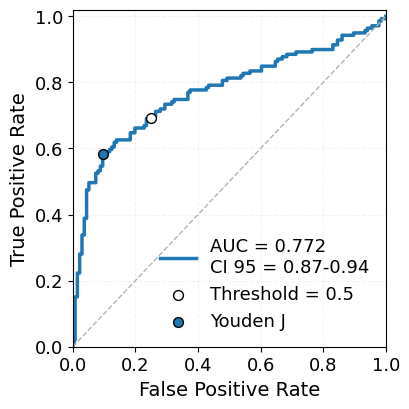

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC
fpr, tpr, thr = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Operating point @ threshold 0.5
i_op = np.argmin(np.abs(thr - 0.5))
fpr_op, tpr_op = fpr[i_op], tpr[i_op]

# Youden J best point
j_scores = tpr - fpr
i_j = np.argmax(j_scores)
fpr_j, tpr_j = fpr[i_j], tpr[i_j]

# Plot (matched aesthetics)
plt.figure(figsize=(4.2, 4.2))
plt.plot(fpr, tpr, lw=2.5, color='#1f77b4', label=f'AUC = {roc_auc:.3f}\nCI 95 = 0.87-0.94')
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='0.7')

plt.scatter([fpr_op], [tpr_op], s=50, edgecolor='k', facecolor='white', zorder=3, label='Threshold = 0.5')
plt.scatter([fpr_j],  [tpr_j],  s=50, edgecolor='k', facecolor='#1f77b4', zorder=3, label='Youden J')

plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.tick_params(axis='both', labelsize=13)
plt.legend(loc='lower right', frameon=False, fontsize=13)

plt.grid(alpha=0.15, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Gaussian_Integral/roc_curve_pub.pdf', dpi=600, bbox_inches='tight')
plt.show()


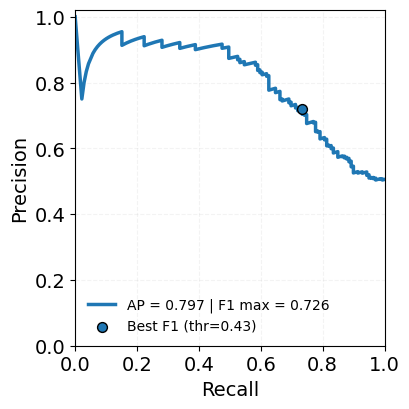

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# build PR arrays from your existing variables
precision, recall, thr = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)

# best F1 (align thresholds properly: precision/recall are len(thr)+1)
f1_scores = 2 * (precision[1:] * recall[1:]) / (precision[1:] + recall[1:] + 1e-8)
i_best = np.argmax(f1_scores)

best_prec = precision[i_best + 1]
best_rec  = recall[i_best + 1]
best_f1   = f1_scores[i_best]
best_thr  = thr[i_best]

plt.figure(figsize=(4.2, 4.2))
plt.plot(recall, precision, lw=2.5, color='#1f77b4',
         label=f'AP = {ap:.3f} | F1 max = {best_f1:.3f}')

plt.scatter([best_rec], [best_prec], s=50, edgecolor='k', facecolor='#1f77b4',
            zorder=3, label=f'Best F1 (thr={best_thr:.2f})')

plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.legend(loc='lower left', frameon=False)
plt.grid(alpha=0.15, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Gaussian_Integral/pr_curve_pub.pdf', dpi=600, bbox_inches="tight")
plt.show()


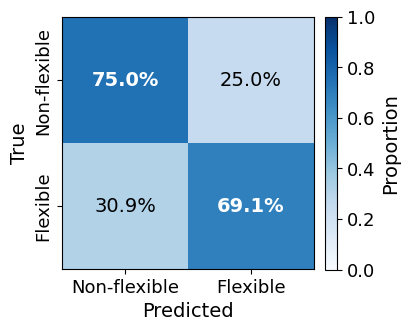

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1) turn probabilities into class predictions
y_true = np.asarray(all_labels).astype(int)
y_pred = (np.asarray(all_probs) >= 0.5).astype(int)

# 2) confusion matrix (rows=true, cols=pred)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# 3) normalize by true class (row-wise)
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "black" if cm_norm[i, j] < 0.5 else "white"
        font_weight = "bold" if i == j else "normal"
        ax.text(j, i, f"{cm_norm[i, j]*100:.1f}%", ha="center", va="center",
                fontsize=14, fontweight=font_weight, color=text_color)

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])

# X tick labels: same style as ROC (tick labels 13)
ax.set_xticklabels(["Non-flexible", "Flexible"], rotation=0, fontsize=13)

# Y tick labels: vertical (rotate 90° anti-clockwise)
ax.set_yticklabels(["Non-flexible", "Flexible"], rotation=90, fontsize=13, va="center")

ax.set_xlabel("Predicted", fontsize=14)
ax.set_ylabel("True", fontsize=14)

# Match tick size
ax.tick_params(axis='both', labelsize=13)

# Colorbar label + tick sizes to match
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Proportion", fontsize=14)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/Gaussian_Integral/confusion_matrix_pub.pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()


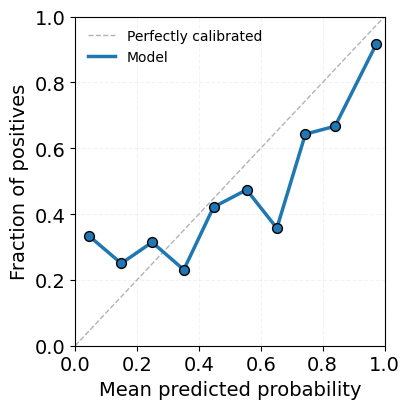

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Curva de calibración (10 bins uniformes)
prob_true, prob_pred = calibration_curve(all_labels, all_probs, n_bins=10, strategy='uniform')

plt.figure(figsize=(4.2, 4.2))

# Línea de referencia (modelo perfectamente calibrado)
plt.plot([0, 1], [0, 1], '--', color='0.7', lw=1, label='Perfectly calibrated')

# Curva del modelo (mismo azul que venís usando)
plt.plot(prob_pred, prob_true, lw=2.5, color='#1f77b4', label='Model')
plt.scatter(prob_pred, prob_true, s=50, edgecolor='k', facecolor='#1f77b4', zorder=3)

# Estética y consistencia
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel('Mean predicted probability', fontsize=14)
plt.ylabel('Fraction of positives', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.grid(alpha=0.15, linestyle='--', linewidth=0.8)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()

# Guarda vectorial (opcional)
plt.savefig('/content/drive/MyDrive/Gaussian_Integral/calibration_curve_pub.pdf', dpi=600, bbox_inches='tight')
plt.show()



In [ ]:
!pip -q install shap
import shap, torch, numpy as np, matplotlib.pyplot as plt
model.eval(); model.to('cpu')  # para SHAP simple y reproducible


ProteinClassifierTCNWithAttentionNoDilation(
  (conv1): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu3): ReLU()
  (conv4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu4): ReLU()
  (attention): AttentionLayer(
    (attention_weights): Linear(in_features=128, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [ ]:
# Suponiendo que tenés un loader de train; si no, usa una muestra del test
bg_list = []
for i, (xb, yb) in enumerate(train_loader):
    bg_list.append(xb.cpu().numpy())
    if len(bg_list) * xb.size(0) >= 64:  # ~64 de background es razonable
        break
background = np.concatenate(bg_list, axis=0)[:64]   # (Bbg, 1, 30)


In [ ]:
background.shape

(64, 1, 30)

In [ ]:
# Explicamos N ejemplos del test (p.ej. los primeros 200 o todos)
X_explain = X_test_t.cpu().numpy()[:200]   # (N, 1, 30)


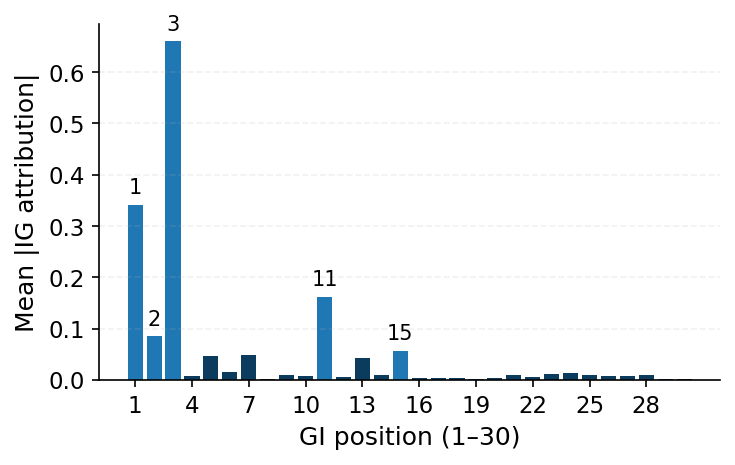

Top‑5 GI positions: [3, 1, 11, 2, 15]  | importances: [0.6599855  0.3417407  0.16214561 0.08524235 0.05719887]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
!pip -q install captum
import torch
from captum.attr import IntegratedGradients
import numpy as np
import matplotlib.pyplot as plt

model.eval().cpu()

X_explain_t = X_explain.float() # (N,1,30)
baseline    = torch.zeros_like(X_explain_t[:1])    # baseline neutro

ig = IntegratedGradients(model)
# target=0 porque tu salida es (B,1)
attr = ig.attribute(X_explain_t, baselines=baseline, target=0, n_steps=128)  # (N,1,30)
attr = attr.squeeze(1).detach().numpy()  # (N,30)

mean_abs = np.abs(attr).mean(axis=0)
# Si ya tienes `attr` o `mean_abs`, puedes saltarte este bloque
# mean_abs = np.abs(attr.squeeze(1).cpu().numpy()).mean(axis=0)  # (30,)

# ------- Tuned plot -------
plt.rcParams['font.family'] = 'DejaVu Sans'   # disponible en Colab

k = 5  # cuántos puntos resaltar
idx_top = np.argsort(-mean_abs)[:k]           # índices 0‑based
x = np.arange(1, 31)
colors = ['#0B3C5D'] * 30                     # azul marino
for i in idx_top:
    colors[i] = '#1f77b4'                     # azul más brillante para top‑k

fig, ax = plt.subplots(figsize=(5.0, 3.2), dpi=150)
bars = ax.bar(x, mean_abs, color=colors, edgecolor='none')

# Etiquetas en los top‑k
for i in idx_top:
    ax.text(i+1, mean_abs[i] + mean_abs.max()*0.02,
            f'{i+1}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('GI position (1–30)', fontsize=12)
ax.set_ylabel('Mean |IG attribution|', fontsize=12)
ax.set_xticks(np.arange(1, 31, 3))
ax.tick_params(axis='both', labelsize=11)
ax.grid(axis='y', alpha=0.18, linestyle='--', linewidth=0.8)

# Limpieza de spines
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

plt.tight_layout()

# Guarda en Drive (PDF y SVG)
out_dir = '/content/drive/MyDrive/Gaussian_Integral'
plt.savefig(f'{out_dir}/ig_importance_bar.pdf', dpi=600, bbox_inches='tight')
plt.savefig(f'{out_dir}/ig_importance_bar.svg', bbox_inches='tight')
plt.show()

print("Top‑5 GI positions:", (idx_top+1).tolist(),
      " | importances:", mean_abs[idx_top])


In [ ]:
pca = pd.read_csv("/content/drive/MyDrive/Gaussian_Integral/pca_results_with_structure.csv")

In [ ]:
pca

,Unnamed: 0,ID_chain,Protein_ID,Distance_to_Centroid,Clusters,X2,alpha,beta,coil
0,1.0,1a62A,1a62,0.262942,3,A,34.0,26.0,40.0
1,2.0,1ab1A,1ab1,1.032308,3,A,48.0,9.0,43.0
2,3.0,1ah7A,1ah7,3.499016,2,A,65.0,1.0,34.0
3,4.0,1ailA,1ail,8.475809,1,A,82.0,0.0,18.0
4,5.0,1aolA,1aol,1.439722,3,A,17.0,27.0,56.0
...,...,...,...,...,...,...,...,...,...
1370,1371.0,7qsuA,7qsu,3.075654,3,A,24.0,40.0,36.0
1371,1372.0,7rm7A,7rm7,1.598490,4,A,69.0,2.0,29.0
1372,1373.0,7s86A,7s86,2.703623,3,A,16.0,32.0,52.0
1373,1374.0,7wabA,7wab,1.520030,4,A,42.0,13.0,45.0


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Verificar intersección de IDs
test_ids_set = set(test_ids)
pca_ids_set = set(pca['Protein_ID'])

intersection = test_ids_set.intersection(pca_ids_set)
print(f"Proteínas del test set encontradas en PCA: {len(intersection)} / {len(test_ids)}")

missing_ids = test_ids_set - pca_ids_set
if missing_ids:
    print("IDs faltantes:", missing_ids)

Proteínas del test set encontradas en PCA: 275 / 275


In [ ]:
y_test = all_labels
y_pred = all_preds


In [ ]:
y_test

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1])

In [ ]:
y_pred

array([0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1])

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Mapear por posición asegurando que filtramos la proteína faltante en los 3 arrays
mask_in_pca = [pid in set(pca['Protein_ID']) for pid in test_ids]

test_ids_filtered = [pid for pid, keep in zip(test_ids, mask_in_pca) if keep]
y_true_filtered = [y for y, keep in zip(y_test, mask_in_pca) if keep]
y_pred_filtered = [y for y, keep in zip(y_pred, mask_in_pca) if keep]

# 2. Construir DataFrame
df_test = pd.DataFrame({
    'Protein_ID': test_ids_filtered,
    'y_true': y_true_filtered,
    'y_pred': y_pred_filtered
})

# 3. Merge con PCA
df_merged = df_test.merge(pca[['Protein_ID', 'Clusters']], on='Protein_ID', how='left')

# 4. Calcular métricas por clúster
metrics_per_cluster = []
for c in sorted(df_merged['Clusters'].dropna().unique()):
    subset = df_merged[df_merged['Clusters'] == c]
    acc = accuracy_score(subset['y_true'], subset['y_pred'])
    prec = precision_score(subset['y_true'], subset['y_pred'])
    rec = recall_score(subset['y_true'], subset['y_pred'])
    f1 = f1_score(subset['y_true'], subset['y_pred'])
    metrics_per_cluster.append([c, len(subset), acc, prec, rec, f1])

df_metrics = pd.DataFrame(metrics_per_cluster,
                          columns=['Cluster', 'N_proteins', 'Accuracy', 'Precision', 'Recall', 'F1'])

print(df_metrics)



   Cluster  N_proteins  Accuracy  Precision    Recall        F1
0        1          19  0.684211   0.636364  0.777778  0.700000
1        2          56  0.732143   0.782609  0.642857  0.705882
2        3         132  0.757576   0.790323  0.720588  0.753846
3        4          68  0.647059   0.647059  0.647059  0.647059


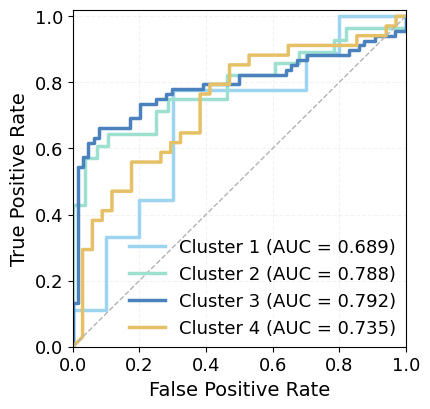

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd

# Filtrar también las probabilidades para que coincidan
probs_filtered = [p for p, keep in zip(all_probs, mask_in_pca) if keep]

df_test_probs = pd.DataFrame({
    'Protein_ID': test_ids_filtered,
    'y_true': y_true_filtered,
    'y_prob': probs_filtered
})

# Merge con pca
df_merged_probs = df_test_probs.merge(pca[['Protein_ID', 'Clusters']], on='Protein_ID', how='left')

cluster_colors = {
    1: "#9dd5f0",  # light blue
    2: "#9de0d0",  # light green
    3: "#4b81bd",  # dark blue
    4: "#e6c066"   # dark yellow
}

plt.figure(figsize=(4.4, 4.2))  # match single ROC style
for c in sorted(df_merged_probs['Clusters'].dropna().unique()):
    subset = df_merged_probs[df_merged_probs['Clusters'] == c]
    if len(subset) == 0:
        continue
    fpr, tpr, _ = roc_curve(subset['y_true'], subset['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=cluster_colors[int(c)], lw=2.5,
             label=f'Cluster {int(c)} (AUC = {roc_auc:.3f})')

# Línea diagonal de azar
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='0.7')

# Labels + ticks to match your ROC figure
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.tick_params(axis='both', labelsize=13)

# move legend slightly down/right (toward the corner)
plt.legend(
    loc="lower right",
    bbox_to_anchor=(1.02, -0.02),  # tweak these two numbers as needed
    frameon=False,
    fontsize=13
)

# light grid (same vibe as ROC)
plt.grid(alpha=0.15, linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Gaussian_Integral/roc_per_cluster.pdf",
            dpi=600, bbox_inches="tight")
plt.show()



In [ ]:
df_merged_probs

,Protein_ID,y_true,y_prob,Clusters
0,5m1m,1,0.123417,2
1,1w2w,0,0.124189,2
2,3gs9,0,0.386246,3
3,6ao8,1,0.837425,4
4,7jfl,1,0.742042,2
...,...,...,...,...
270,4csb,1,0.928576,3
271,1l2p,0,0.278983,1
272,1r5l,0,0.330566,2
273,4lq4,1,0.908005,3


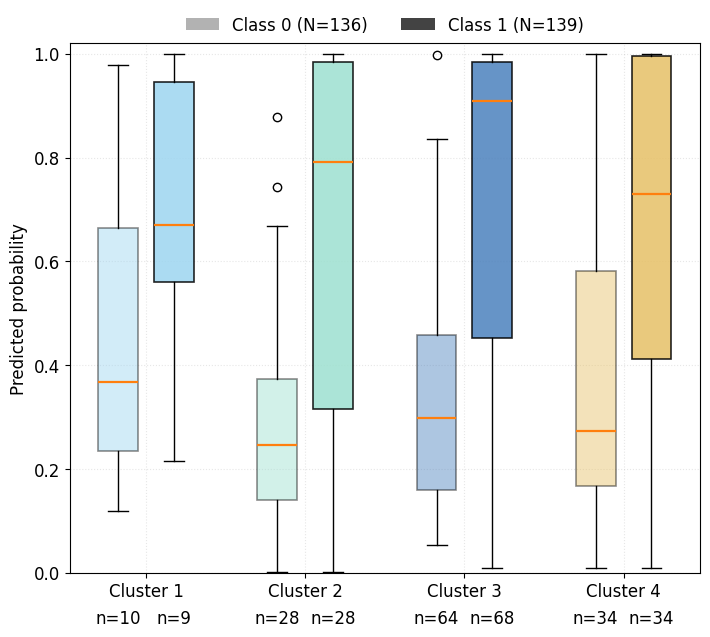

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Partimos de df_merged_probs con columnas: Protein_ID, y_true (0/1), y_prob (0–1), Clusters (1–4)

clusters = sorted(df_merged_probs['Clusters'].dropna().unique())
offset = 0.18  # separación entre cajas dentro del clúster

# Prepara datos por (cluster, clase)
data0, data1, ns0, ns1 = [], [], [], []
for c in clusters:
    sub = df_merged_probs[df_merged_probs['Clusters'] == c]
    s0 = sub[sub['y_true'] == 0]['y_prob'].values
    s1 = sub[sub['y_true'] == 1]['y_prob'].values
    data0.append(s0)
    data1.append(s1)
    ns0.append(len(s0)); ns1.append(len(s1))

# Reducimos separación global entre grupos
x = np.arange(len(clusters)) * 0.8  # antes era *1.0

# Colores por cluster (tu mapping)
cluster_colors = {
    1: "#9dd5f0",  # light blue
    2: "#9de0d0",  # light green
    3: "#4b81bd",  # dark blue
    4: "#e6c066"   # dark yellow
}

colors0 = [cluster_colors[c] for c in clusters]
colors1 = [cluster_colors[c] for c in clusters]

plt.figure(figsize=(7.2, 6))

offset = 0.14  # antes 0.18

bp0 = plt.boxplot(
    data0, positions=x - offset, widths=0.20, patch_artist=True, manage_ticks=False,
    boxprops=dict(linewidth=1.2), medianprops=dict(linewidth=1.6),
    whiskerprops=dict(linewidth=1.0), capprops=dict(linewidth=1.0)
)
bp1 = plt.boxplot(
    data1, positions=x + offset, widths=0.20, patch_artist=True, manage_ticks=False,
    boxprops=dict(linewidth=1.2), medianprops=dict(linewidth=1.6),
    whiskerprops=dict(linewidth=1.0), capprops=dict(linewidth=1.0)
)

# Colorear cajas según cluster; usar alpha para diferenciar clase
for patch, col in zip(bp0['boxes'], colors0):
    patch.set_facecolor(col); patch.set_alpha(0.45)
for patch, col in zip(bp1['boxes'], colors1):
    patch.set_facecolor(col); patch.set_alpha(0.85)

# Ejes y estilo
plt.xticks(x, [f'Cluster {c}' for c in clusters], fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Predicted probability', fontsize=12)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3, linestyle=':')

# Leyenda: más baja y más cerca del plot
legend_patches = [
    Patch(facecolor="#555555", alpha=0.45, label=f'Class 0 (N={sum(ns0)})'),
    Patch(facecolor="#222222", alpha=0.85, label=f'Class 1 (N={sum(ns1)})')
]
plt.legend(
    handles=legend_patches,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),   # was 1.18
    ncol=2,
    frameon=False,
    fontsize=12
)

# Etiquetas de N por clúster: bájalas un poquito
y_n = -0.07  # was -0.05
for i, (n0, n1) in enumerate(zip(ns0, ns1)):
    plt.text(x[i] - offset, y_n, f'n={n0}', ha='center', va='top', fontsize=12, transform=plt.gca().transData)
    plt.text(x[i] + offset, y_n, f'n={n1}', ha='center', va='top', fontsize=12, transform=plt.gca().transData)

plt.tight_layout()
plt.subplots_adjust(top=0.99)  # was 0.86

plt.savefig(
    "/content/drive/MyDrive/Gaussian_Integral/boxplot_probs.pdf",
    dpi=600, bbox_inches='tight', pad_inches=0.02
)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# === 1) Subset con los 275 IDs ===
# Aseguramos que el orden de test_ids sea el mismo que el de y_true / y_pred
data_idx = data.set_index(1, drop=False)
subset = data_idx.loc[test_ids].copy()  # 275 filas en el mismo orden que test_ids
X_gi = subset.iloc[:, 3:33].to_numpy(dtype=float)  # columnas 3..32 = 30 GI features

# === 2) Escalar antes del PCA ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_gi)

# === 3) PCA
pca_model = PCA(n_components=2, random_state=0)
X_pca = pca_model.fit_transform(X_scaled)

# === 4) DataFrame PCA + etiquetas y predicciones
df_pca_test = pd.DataFrame({
    'Protein_ID': test_ids,
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'y_true': y_test,      # usa y_test del análisis original (275 elementos)
    'y_pred': y_pred,      # usa y_pred del análisis original (275 elementos)
})

In [ ]:
df_pca_test

,Protein_ID,PC1,PC2,y_true,y_pred
0,5m1m,3.857209,1.259174,1,0
1,1w2w,2.634738,1.002113,0,0
2,3gs9,-2.444528,-0.385036,0,0
3,6ao8,0.993021,4.085936,1,1
4,7jfl,1.584013,-3.125654,1,1
...,...,...,...,...,...
270,4csb,-3.178438,-1.934717,1,1
271,1l2p,10.139334,-3.614460,0,0
272,1r5l,1.874809,1.740116,0,0
273,4lq4,-1.673505,0.610371,1,1


In [ ]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score

def train_model(model, train_loader, val_loader, hyperparams, device='cuda'):
    criterion = torch.nn.BCELoss()  # si tus logits no pasan por sigmoid, cambia a BCEWithLogitsLoss
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=hyperparams['learning_rate'],
                                 weight_decay=hyperparams['weight_decay'])
    model.to(device)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_wts = model.state_dict()

    # ---> historiales por epoch
    hist_train_loss = []
    hist_val_loss   = []
    hist_train_acc  = []
    hist_val_acc    = []

    for epoch in range(hyperparams['num_epochs']):
        # --------- TRAIN ----------
        model.train()
        train_loss_sum, n_train = 0.0, 0
        y_true_train, y_pred_train = [], []

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)                 # (B,1) con sigmoide aplicado dentro del modelo
            loss = criterion(outputs, y_batch)       # BCELoss espera probs en [0,1]
            loss.backward()
            optimizer.step()

            bs = y_batch.size(0)
            train_loss_sum += loss.item() * bs
            n_train += bs

            y_true_train += y_batch.detach().cpu().numpy().flatten().tolist()
            y_pred_train += (outputs.detach().cpu().numpy().flatten() > 0.5).tolist()

        train_loss = train_loss_sum / max(n_train, 1)
        train_acc  = accuracy_score(y_true_train, y_pred_train)

        # --------- VAL ----------
        model.eval()
        val_loss_sum, n_val = 0.0, 0
        y_true_val, y_pred_val = [], []
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                val_out = model(x_val)
                loss = criterion(val_out, y_val)

                bs = y_val.size(0)
                val_loss_sum += loss.item() * bs
                n_val += bs

                y_true_val += y_val.cpu().numpy().flatten().tolist()
                y_pred_val += (val_out.cpu().numpy().flatten() > 0.5).tolist()

        val_loss = val_loss_sum / max(n_val, 1)
        val_acc  = accuracy_score(y_true_val, y_pred_val)

        # guardo historial
        hist_train_loss.append(train_loss)
        hist_val_loss.append(val_loss)
        hist_train_acc.append(train_acc)
        hist_val_acc.append(val_acc)

        print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"train_acc={train_acc:.3f} | val_acc={val_acc:.3f}")

        # early stopping por val_loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= hyperparams['patience']:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_wts)

    history = {
        "train_loss": hist_train_loss,
        "val_loss":   hist_val_loss,
        "train_acc":  hist_train_acc,
        "val_acc":    hist_val_acc
    }
    return model, history


In [ ]:
def train_and_validate_kfold(all_dataloaders, hyperparams):
    trained_models  = []
    val_accuracies  = []
    fold_histories  = []  # <--- nuevo

    for fold in range(len(all_dataloaders)):
        print(f"\n🟦 Fold {fold}")
        train_loader = all_dataloaders[fold]["train"]
        val_loader   = all_dataloaders[fold]["val"]

        model = ProteinClassifierTCNWithAttentionNoDilation(
            input_dim=hyperparams['input_dim'],
            hidden_dim=hyperparams['hidden_dim'],
            output_dim=hyperparams['output_dim'],
            kernel_size=hyperparams['kernel_size']
        )

        trained_model, history = train_model(model, train_loader, val_loader, hyperparams)
        trained_models.append(trained_model)
        fold_histories.append(history)

        # Eval final en val del fold (como ya hacías)
        y_true, y_pred = [], []
        trained_model.eval()
        with torch.no_grad():
            for x_val, y_val in val_loader:
                out = trained_model(x_val.cuda())
                y_true += y_val.cpu().numpy().flatten().tolist()
                y_pred += (out.cpu().numpy().flatten() > 0.5).tolist()

        val_acc = accuracy_score(y_true, y_pred)
        val_accuracies.append(val_acc)
        print(f"✅ Fold {fold} finished — Final Val Acc: {val_acc:.3f}")

    for fold, acc in enumerate(val_accuracies):
        print(f"Fold {fold} — Val Acc: {acc:.3f}")
    print(f"\n📈 Average Val Acc: {np.mean(val_accuracies):.3f}")

    return trained_models, val_accuracies, fold_histories  # <--- devuelve histories



🟦 Fold 0
Epoch 001 | train_loss=0.6933 | val_loss=0.6941 | train_acc=0.479 | val_acc=0.495
Epoch 002 | train_loss=0.6869 | val_loss=0.6894 | train_acc=0.567 | val_acc=0.568
Epoch 003 | train_loss=0.6773 | val_loss=0.6852 | train_acc=0.601 | val_acc=0.559
Epoch 004 | train_loss=0.6546 | val_loss=0.6898 | train_acc=0.603 | val_acc=0.564
Epoch 005 | train_loss=0.6575 | val_loss=0.6798 | train_acc=0.594 | val_acc=0.591
Epoch 006 | train_loss=0.6390 | val_loss=0.7061 | train_acc=0.629 | val_acc=0.514
Epoch 007 | train_loss=0.6592 | val_loss=0.6819 | train_acc=0.590 | val_acc=0.600
Epoch 008 | train_loss=0.6363 | val_loss=0.6844 | train_acc=0.613 | val_acc=0.591
Epoch 009 | train_loss=0.6251 | val_loss=0.6496 | train_acc=0.639 | val_acc=0.623
Epoch 010 | train_loss=0.6328 | val_loss=0.6723 | train_acc=0.622 | val_acc=0.545
Epoch 011 | train_loss=0.6154 | val_loss=0.6796 | train_acc=0.656 | val_acc=0.614
Epoch 012 | train_loss=0.6155 | val_loss=0.6396 | train_acc=0.643 | val_acc=0.664
Epoch 

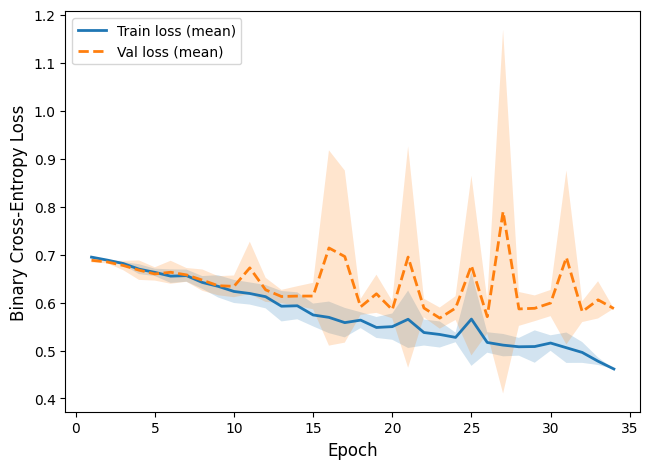

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cv_loss_curves(fold_histories, outfile_pdf="classifier_loss_curve_cv.pdf"):
    # obtener longitudes por fold
    lens_train = [len(h["train_loss"]) for h in fold_histories]
    lens_val   = [len(h["val_loss"])   for h in fold_histories]
    T = max(max(lens_train), max(lens_val))  # longitud máxima

    # matriz (fold x T) con NaN padding
    def to_matrix(key):
        M = np.full((len(fold_histories), T), np.nan, dtype=float)
        for i, h in enumerate(fold_histories):
            arr = np.asarray(h[key], dtype=float)
            M[i, :len(arr)] = arr
        return M

    M_train = to_matrix("train_loss")
    M_val   = to_matrix("val_loss")

    # estadísticos ignorando NaN (por early stopping)
    mean_train = np.nanmean(M_train, axis=0)
    std_train  = np.nanstd(M_train, axis=0)
    mean_val   = np.nanmean(M_val,   axis=0)
    std_val    = np.nanstd(M_val,    axis=0)

    epochs = np.arange(1, T+1)

    plt.figure(figsize=(6.6, 4.8))
    # Train
    plt.plot(epochs, mean_train, label="Train loss (mean)", linewidth=2)
    plt.fill_between(epochs, mean_train-std_train, mean_train+std_train, alpha=0.2)
    # Val
    plt.plot(epochs, mean_val,   label="Val loss (mean)", linewidth=2, linestyle="--")
    plt.fill_between(epochs, mean_val-std_val, mean_val+std_val, alpha=0.2)

    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)
    plt.legend()
    plt.tight_layout()
    #plt.savefig(outfile_pdf, dpi=600, bbox_inches="tight", format="pdf")
    plt.show()

# Uso (después de entrenar):
trained_models, val_accuracies, fold_histories = train_and_validate_kfold(all_dataloaders, HYPERPARAMS)
plot_cv_loss_curves(fold_histories, "classifier_loss_curve_cv.pdf")


In [ ]:
trained_models, val_accuracies, fold_histories = train_and_validate_kfold(all_dataloaders, HYPERPARAMS)



🟦 Fold 0
Epoch 001 | train_loss=0.6901 | val_loss=0.6924 | train_acc=0.519 | val_acc=0.536
Epoch 002 | train_loss=0.6748 | val_loss=0.6827 | train_acc=0.584 | val_acc=0.564
Epoch 003 | train_loss=0.6538 | val_loss=0.6925 | train_acc=0.606 | val_acc=0.568
Epoch 004 | train_loss=0.6465 | val_loss=0.6874 | train_acc=0.603 | val_acc=0.545
Epoch 005 | train_loss=0.6431 | val_loss=0.6962 | train_acc=0.613 | val_acc=0.500
Epoch 006 | train_loss=0.6449 | val_loss=0.6839 | train_acc=0.604 | val_acc=0.582
Epoch 007 | train_loss=0.6464 | val_loss=0.6822 | train_acc=0.596 | val_acc=0.586
Epoch 008 | train_loss=0.6282 | val_loss=0.6719 | train_acc=0.633 | val_acc=0.550
Epoch 009 | train_loss=0.6258 | val_loss=0.7026 | train_acc=0.635 | val_acc=0.582
Epoch 010 | train_loss=0.6091 | val_loss=0.6526 | train_acc=0.655 | val_acc=0.636
Epoch 011 | train_loss=0.5925 | val_loss=0.6352 | train_acc=0.676 | val_acc=0.623
Epoch 012 | train_loss=0.5647 | val_loss=0.6239 | train_acc=0.710 | val_acc=0.641
Epoch 

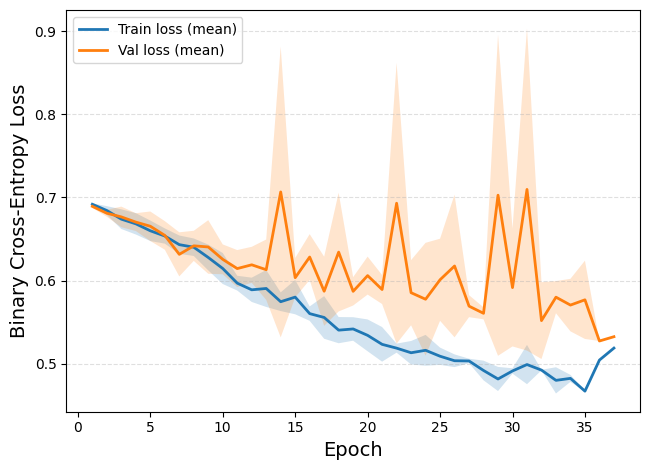

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cv_loss_curves(fold_histories, outfile_pdf="classifier_loss_curve_cv.pdf"):
    T = max(max(len(h["train_loss"]) for h in fold_histories),
            max(len(h["val_loss"])   for h in fold_histories))

    def to_matrix(key):
        M = np.full((len(fold_histories), T), np.nan)
        for i, h in enumerate(fold_histories):
            a = np.asarray(h[key], dtype=float)
            M[i, :len(a)] = a
        return M

    Mtr, Mval = to_matrix("train_loss"), to_matrix("val_loss")
    mean_tr, std_tr  = np.nanmean(Mtr,  axis=0), np.nanstd(Mtr,  axis=0)
    mean_val, std_val= np.nanmean(Mval, axis=0), np.nanstd(Mval, axis=0)
    epochs = np.arange(1, T+1)

    plt.figure(figsize=(6.6, 4.8))
    plt.plot(epochs, mean_tr,  label="Train loss (mean)", linewidth=2)
    plt.fill_between(epochs, mean_tr-std_tr,  mean_tr+std_tr,  alpha=0.2)
    plt.plot(epochs, mean_val, label="Val loss (mean)", linewidth=2)  # sin linestyle
    plt.fill_between(epochs, mean_val-std_val, mean_val+std_val, alpha=0.2)

    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Binary Cross-Entropy Loss", fontsize=14)
    plt.legend()

    # Grid estético solo en eje Y
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Gaussian_Integral/loss_curve_classifier.pdf',
                dpi=600, bbox_inches="tight", format="pdf")
    plt.show()

# Llamada
plot_cv_loss_curves(fold_histories, "classifier_loss_curve_cv.pdf")





In [ ]:
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34
0,1,1a62,A,1.2970,0.4236,3.645,0.02173,-0.3509,1.23600,1.6110,0.3898,-0.4463,0.08352,1.6150,-0.1089,0.2776,0.1930,1.3400,-0.02027,0.23100,-0.20670,-0.00054,0.00651,-0.54390,0.04694,0.12740,0.12250,-0.41030,-0.10150,0.15820,0.06054,0.02185,-0.10650,1.37,1
1,2,1ab1,A,0.4890,0.9617,2.546,0.51950,0.5938,0.60290,0.6019,1.7940,1.1130,-0.09591,0.7201,-2.8930,1.1170,-1.9320,0.8952,0.14270,0.30250,0.36870,0.65410,0.08276,2.83200,-0.71570,-0.69990,0.54800,-0.59130,-1.49600,5.83800,-2.31500,-3.79100,-2.05500,0.66,0
2,3,1ah7,A,2.6040,2.3810,5.383,2.49100,3.4620,3.01300,3.5740,0.6332,1.6980,1.21300,3.0790,1.2650,3.1840,0.8268,3.2690,2.35800,0.76080,2.55000,0.61380,-0.17170,-0.42660,1.38100,0.05350,0.01457,0.65310,-0.25200,-0.15760,1.03500,0.46810,0.24570,0.68,0
3,4,1ail,A,0.7441,2.9330,3.353,3.17300,2.1860,2.32700,1.4560,3.6950,2.0010,2.29000,0.8676,4.6190,1.8710,2.0710,1.1210,2.93100,3.16100,2.52800,3.63600,2.77200,7.23200,5.55400,0.86000,1.64100,3.32100,0.93770,4.64800,5.41800,6.74300,5.04800,1.42,1
4,5,1aol,A,2.4240,0.5442,4.530,0.16640,0.7012,0.48890,2.0390,0.2947,0.2938,-0.39170,2.6940,-0.5530,1.4340,-1.3180,2.9770,0.02937,0.06954,-0.03164,0.07936,0.14420,0.19820,-0.00322,0.04921,-0.09331,0.10150,-0.12090,-0.24700,-0.26600,-0.29280,0.37130,1.05,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1369,1382,7p46,A,2.9870,2.2660,4.711,2.31900,2.6750,2.90100,2.9890,0.5693,0.9535,0.87220,2.0510,0.6791,2.5600,0.3557,2.2000,2.16200,0.61520,1.30000,0.57230,0.05129,0.09874,1.09500,-0.09983,-0.03797,0.35300,-0.03707,-0.29740,0.37460,0.22170,0.00724,3.29,1
1370,1383,7qsu,A,3.8900,0.2467,5.555,0.04664,0.6219,0.14940,3.2260,0.1590,-0.3252,-0.01876,3.5490,-0.3838,1.1410,-2.0990,4.5400,-0.00630,0.01024,0.03960,0.02350,-0.01348,-0.19530,0.14820,0.06348,-0.07079,-0.02899,0.06183,0.32720,-0.10190,-0.26440,-0.25220,1.08,0
1371,1384,7rm7,A,2.3600,2.0850,5.225,2.12800,2.9110,2.75600,3.3020,0.7077,0.8281,0.24710,2.6500,-0.9938,3.2580,-0.9767,3.3270,1.94900,0.66070,0.77440,0.75570,0.10190,-0.31750,-0.70210,-0.04078,0.07988,0.07872,0.06016,0.42410,-1.83300,-0.47010,-0.40160,3.79,1
1372,1385,7s86,A,0.8823,-0.2941,3.040,0.02828,-0.1691,-0.03484,0.7385,0.4276,-1.5890,-3.08800,1.6400,-0.5839,0.4428,-0.6651,1.3190,-0.02540,-0.04964,0.47510,-0.03599,1.75000,-0.74740,0.51210,5.93000,-4.10800,2.56300,-7.05400,-2.42800,-0.38280,-1.19600,3.20300,3.88,1


In [ ]:
data[34]

,34
0,1
1,0
2,0
3,1
4,0
...,...
1369,1
1370,0
1371,1
1372,1


##ABLATION NATION

Epoch 1 — Train Acc: 0.539, Val Acc: 0.509, Val Loss: 0.7121
Epoch 2 — Train Acc: 0.576, Val Acc: 0.495, Val Loss: 0.6908
Epoch 3 — Train Acc: 0.590, Val Acc: 0.550, Val Loss: 0.7552
Epoch 4 — Train Acc: 0.584, Val Acc: 0.573, Val Loss: 0.7141
Epoch 5 — Train Acc: 0.594, Val Acc: 0.500, Val Loss: 0.6928
Epoch 6 — Train Acc: 0.567, Val Acc: 0.550, Val Loss: 0.6847
Epoch 7 — Train Acc: 0.627, Val Acc: 0.555, Val Loss: 0.7004
Epoch 8 — Train Acc: 0.617, Val Acc: 0.577, Val Loss: 0.6790
Epoch 9 — Train Acc: 0.629, Val Acc: 0.568, Val Loss: 0.7170
Epoch 10 — Train Acc: 0.605, Val Acc: 0.595, Val Loss: 0.6829
Epoch 11 — Train Acc: 0.622, Val Acc: 0.595, Val Loss: 0.6792
Epoch 12 — Train Acc: 0.635, Val Acc: 0.582, Val Loss: 0.6958
Epoch 13 — Train Acc: 0.668, Val Acc: 0.623, Val Loss: 0.6772
Epoch 14 — Train Acc: 0.702, Val Acc: 0.614, Val Loss: 0.6720
Epoch 15 — Train Acc: 0.663, Val Acc: 0.632, Val Loss: 0.6813
Epoch 16 — Train Acc: 0.679, Val Acc: 0.573, Val Loss: 0.6559
Epoch 17 — Train 

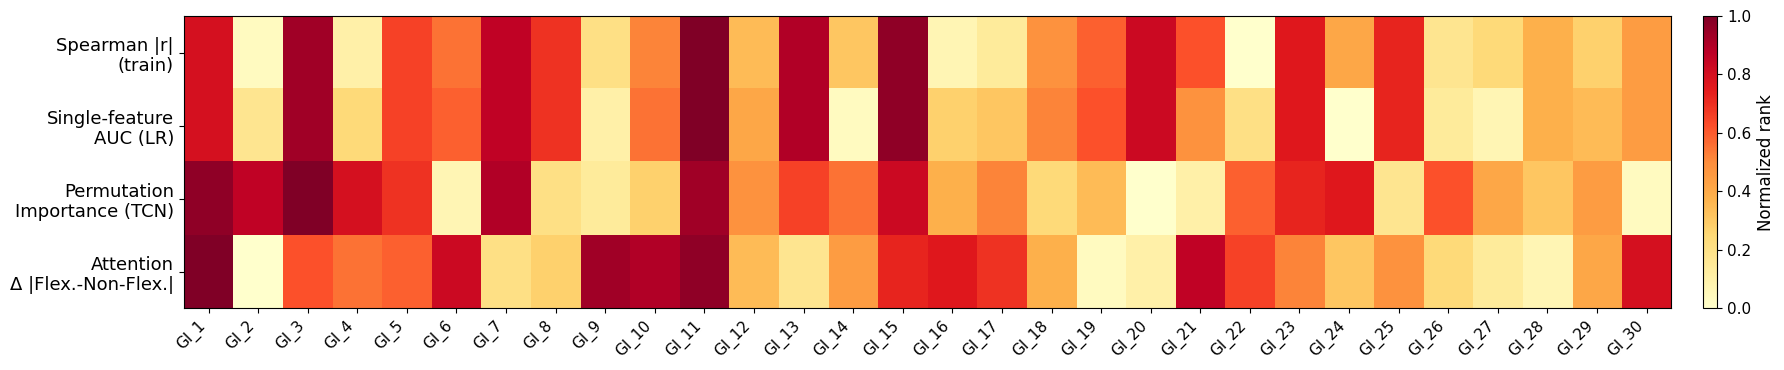

Saved:
/content/drive/MyDrive/Gaussian_Integral/Ablation_Class_Heatmap/GI_interpretability_heatmap_4methods_pretty.png
/content/drive/MyDrive/Gaussian_Integral/Ablation_Class_Heatmap/GI_interpretability_heatmap_4methods_pretty.pdf
/content/drive/MyDrive/Gaussian_Integral/Ablation_Class_Heatmap/gi_interpretability_raw_scores.csv
/content/drive/MyDrive/Gaussian_Integral/Ablation_Class_Heatmap/gi_interpretability_normalized_rank.csv


In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ============================================================
# CONFIG
# ============================================================
JSON_PATH = "/content/drive/MyDrive/Gaussian_Integral/folds_gaussian_integral_ids_clean.json"
OUT_DIR   = "/content/drive/MyDrive/Gaussian_Integral/Ablation_Class_Heatmap"
os.makedirs(OUT_DIR, exist_ok=True)

PDB_COL_IDX   = 1            # dataframe column index with PDB id like "1a62"
FEATURE_SLICE = slice(3, 33) # GI columns 3..32 inclusive => iloc[:, 3:33]
LABEL_COL     = 34

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

GI_NAMES = [f"GI_{i}" for i in range(1, 31)]
METHODS  = [
    "Spearman |r| (train)",
    "Single-feature AUC (LR)",
    "Permutation Importance (TCN)",
    "Attention diff |Flex.−Non-Flex.|"
]

# ============================================================
# HELPERS
# ============================================================
def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

def row_norm_rank(values):
    """
    Convert an array of shape (30,) to normalized rank in [0,1],
    where 1 = most important (largest value).
    """
    v = np.asarray(values, dtype=float)
    # handle NaNs: push them to the bottom
    nan_mask = np.isnan(v)
    v2 = v.copy()
    v2[nan_mask] = -np.inf

    order = np.argsort(-v2)  # descending
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(v2), dtype=float)  # 0 = best

    # normalize: best -> 1, worst -> 0
    if len(v2) > 1:
        norm = 1.0 - (ranks / (len(v2) - 1))
    else:
        norm = np.ones_like(ranks)

    # NaNs become 0
    norm[nan_mask] = 0.0
    return norm

def get_fold_entry(splits, fold_id):
    fold_entry = splits["folds"][fold_id]
    # robust if folds not aligned
    if isinstance(fold_entry, dict) and ("fold" in fold_entry) and (fold_entry["fold"] != fold_id):
        fold_entry = next(d for d in splits["folds"] if d.get("fold") == fold_id)
    return fold_entry

def subset_df_by_ids(df, id_list, pdb_col_idx=PDB_COL_IDX):
    pdb_series = df.iloc[:, pdb_col_idx].astype(str).str.lower()
    id_set = set([str(x).lower() for x in id_list])
    return df.loc[pdb_series.isin(id_set)].copy()

def df_to_xy(df):
    X = df.iloc[:, FEATURE_SLICE].to_numpy(dtype=np.float32)  # (N,30)
    y = df[LABEL_COL].to_numpy(dtype=np.float32).reshape(-1)  # (N,)
    # Conv1d expects (N,1,30)
    X_cnn = X.reshape(-1, 1, X.shape[1])
    return X, X_cnn, y

@torch.no_grad()
def predict_probs(model, X_cnn, batch_size=256, device=DEVICE):
    model.eval()
    probs = []
    n = X_cnn.shape[0]
    for i in range(0, n, batch_size):
        xb = torch.from_numpy(X_cnn[i:i+batch_size]).to(device).float()
        pb = model(xb).detach().cpu().numpy().ravel()
        probs.append(pb)
    return np.concatenate(probs)

# ============================================================
# MODEL (same architecture, but attention caches weights)
# ============================================================
class AttentionLayerWithCache(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention_weights = nn.Linear(hidden_dim, 1)
        self.softmax = nn.Softmax(dim=1)
        self.last_attn = None  # will store (B, seq_len)

    def forward(self, x):
        # x: (B, hidden_dim, seq_len)
        attn_scores = self.attention_weights(x.permute(0, 2, 1))  # (B, seq_len, 1)
        attn_scores = self.softmax(attn_scores.squeeze(-1))       # (B, seq_len)
        self.last_attn = attn_scores  # cache for interpretability
        attn_applied = torch.bmm(x, attn_scores.unsqueeze(-1)).squeeze(-1)  # (B, hidden_dim)
        return attn_applied

class ProteinClassifierTCNWithAttentionNoDilation_Cached(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, hidden_dim, kernel_size=kernel_size, dilation=1, padding=kernel_size//2)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=kernel_size, dilation=1, padding=kernel_size//2)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=kernel_size, dilation=1, padding=kernel_size//2)
        self.relu3 = nn.ReLU()
        self.conv4 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=kernel_size, dilation=1, padding=kernel_size//2)
        self.relu4 = nn.ReLU()

        self.attention = AttentionLayerWithCache(hidden_dim)

        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.relu3(self.conv3(x))
        x = self.relu4(self.conv4(x))
        x = self.attention(x)
        x = self.sigmoid(self.fc(x))
        return x

# ============================================================
# YOUR TRAINING LOOP (unchanged, assumes you already defined train_model)
# - It must accept (model, train_loader, val_loader, hyperparams, device)
# ============================================================

# ============================================================
# LOAD SPLITS ONCE
# ============================================================
with open(JSON_PATH, "r") as f:
    splits = json.load(f)

NUM_FOLDS = len(splits["folds"])

# ============================================================
# ROW 1: Spearman |r| (train)
# ============================================================
spearman_per_fold = []

for fold_id in range(NUM_FOLDS):
    fold = get_fold_entry(splits, fold_id)
    train_df = subset_df_by_ids(data, fold["train_ids"], pdb_col_idx=PDB_COL_IDX)

    # Spearman using pandas (fast + no scipy dependency)
    # compute corr between each GI column and label
    tmp = train_df.iloc[:, FEATURE_SLICE].copy()
    tmp[LABEL_COL] = train_df[LABEL_COL].values
    corrs = tmp.corr(method="spearman")[LABEL_COL].iloc[:-1].values  # exclude self-corr
    spearman_per_fold.append(np.abs(corrs))

spearman_row = np.nanmean(np.vstack(spearman_per_fold), axis=0)  # (30,)

# ============================================================
# ROW 2: Single-feature AUC (LR) evaluated on VAL
# ============================================================
lr_auc_per_fold = []

for fold_id in range(NUM_FOLDS):
    fold = get_fold_entry(splits, fold_id)
    train_df = subset_df_by_ids(data, fold["train_ids"], pdb_col_idx=PDB_COL_IDX)
    val_df   = subset_df_by_ids(data, fold["val_ids"],   pdb_col_idx=PDB_COL_IDX)

    Xtr, _, ytr = df_to_xy(train_df)
    Xva, _, yva = df_to_xy(val_df)

    aucs = []
    for j in range(30):
        xtr1 = Xtr[:, [j]]
        xva1 = Xva[:, [j]]

        scaler = StandardScaler()
        xtr1s = scaler.fit_transform(xtr1)
        xva1s = scaler.transform(xva1)

        clf = LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            class_weight="balanced"
        )
        clf.fit(xtr1s, ytr.astype(int))
        p = clf.predict_proba(xva1s)[:, 1]
        aucs.append(safe_auc(yva, p))

    lr_auc_per_fold.append(np.array(aucs, dtype=float))

lr_auc_row = np.nanmean(np.vstack(lr_auc_per_fold), axis=0)  # (30,)

# ============================================================
# ROWS 3+4: Train TCN per fold, then:
#  - permutation importance on VAL (delta AUC)
#  - attention diff |mean attn(class1) - mean attn(class0)|
# ============================================================
perm_delta_auc_per_fold = []
attn_diff_per_fold = []

for fold_dict in all_dataloaders:
    fold_id = fold_dict["fold"]
    train_loader = fold_dict["train"]
    val_loader   = fold_dict["val"]

    # Train model once per fold
    model = ProteinClassifierTCNWithAttentionNoDilation_Cached(
        input_dim=HYPERPARAMS["input_dim"],
        hidden_dim=HYPERPARAMS["hidden_dim"],
        output_dim=HYPERPARAMS["output_dim"],
        kernel_size=HYPERPARAMS["kernel_size"],
    )
    model = train_model(model, train_loader, val_loader, HYPERPARAMS, device=DEVICE)
    model.to(DEVICE)

    # ---- Extract full VAL arrays once (for permutation + attention)
    Xv_list, yv_list = [], []
    for xb, yb in val_loader:
        Xv_list.append(xb.numpy())          # (B,1,30)
        yv_list.append(yb.numpy().ravel())  # (B,)
    Xv = np.concatenate(Xv_list, axis=0).astype(np.float32)
    yv = np.concatenate(yv_list, axis=0).astype(np.float32)

    # ---- Baseline AUC on VAL
    p_base = predict_probs(model, Xv, batch_size=256, device=DEVICE)
    auc_base = safe_auc(yv, p_base)

    # ---- Permutation importance: shuffle feature j across samples (VAL)
    deltas = []
    rng = np.random.default_rng(SEED + fold_id)
    for j in range(30):
        Xp = Xv.copy()
        perm = rng.permutation(Xp.shape[0])
        Xp[:, 0, j] = Xp[perm, 0, j]

        p_perm = predict_probs(model, Xp, batch_size=256, device=DEVICE)
        auc_perm = safe_auc(yv, p_perm)

        deltas.append(auc_base - auc_perm if (not np.isnan(auc_base) and not np.isnan(auc_perm)) else np.nan)

    perm_delta_auc_per_fold.append(np.array(deltas, dtype=float))

    # ---- Attention diff: collect attention weights for each sample on VAL
    # We run forward passes and read model.attention.last_attn
    attn_all = []
    y_all = []

    model.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE).float()
            _ = model(xb)  # forward fills last_attn
            attn = model.attention.last_attn.detach().cpu().numpy()  # (B,30)
            attn_all.append(attn)
            y_all.append(yb.numpy().ravel())

    attn_all = np.concatenate(attn_all, axis=0)  # (N,30)
    y_all    = np.concatenate(y_all, axis=0).astype(int)

    if len(np.unique(y_all)) < 2:
        attn_diff = np.full(30, np.nan, dtype=float)
    else:
        mean1 = attn_all[y_all == 1].mean(axis=0)
        mean0 = attn_all[y_all == 0].mean(axis=0)
        attn_diff = np.abs(mean1 - mean0)

    attn_diff_per_fold.append(attn_diff.astype(float))

# Aggregate across folds
perm_row  = np.nanmean(np.vstack(perm_delta_auc_per_fold), axis=0)  # (30,)
attn_row  = np.nanmean(np.vstack(attn_diff_per_fold), axis=0)       # (30,)

# ============================================================
# BUILD TABLES + HEATMAP
# ============================================================
raw = np.vstack([spearman_row, lr_auc_row, perm_row, attn_row])  # (4,30)
raw_df = pd.DataFrame(raw, index=METHODS, columns=GI_NAMES)
raw_df.to_csv(os.path.join(OUT_DIR, "gi_interpretability_raw_scores.csv"))

rank = np.vstack([row_norm_rank(raw[i]) for i in range(raw.shape[0])])
rank_df = pd.DataFrame(rank, index=METHODS, columns=GI_NAMES)
rank_df.to_csv(os.path.join(OUT_DIR, "gi_interpretability_normalized_rank.csv"))

# Plot heatmap
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np
import os

# --- Updated row labels (with line breaks + triangle) ---
METHODS_PRETTY = [
    "Spearman |r|\n(train)",
    "Single-feature\nAUC (LR)",
    "Permutation\nImportance (TCN)",
    "Attention\nΔ |Flex.-Non-Flex.|"
]

# --- Plot heatmap with larger fonts (+2 pt overall) ---
plt.figure(figsize=(18, 3.8))  # a touch taller for the multi-line y labels
im = plt.imshow(rank, aspect="auto", vmin=0, vmax=1, cmap="YlOrRd")

plt.yticks(np.arange(len(METHODS_PRETTY)), METHODS_PRETTY, fontsize=13)  # was ~11
plt.xticks(np.arange(30), GI_NAMES, rotation=45, ha="right", fontsize=11) # was ~9

# Colorbar: remove "1 = most important"
cbar = plt.colorbar(im, fraction=0.03, pad=0.02)
cbar.set_label("Normalized rank", fontsize=12)  # was default/smaller
cbar.ax.tick_params(labelsize=11)               # bump tick labels too

plt.tight_layout()

out_png = os.path.join(OUT_DIR, "GI_interpretability_heatmap_4methods_pretty.png")
out_pdf = os.path.join(OUT_DIR, "GI_interpretability_heatmap_4methods_pretty.pdf")
plt.savefig(out_png, dpi=300)
plt.savefig(out_pdf)
plt.show()

print("Saved:")
print(out_png)
print(out_pdf)
print(os.path.join(OUT_DIR, "gi_interpretability_raw_scores.csv"))
print(os.path.join(OUT_DIR, "gi_interpretability_normalized_rank.csv"))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# --- Paths ---
NPZ_NOATTN = "/content/drive/MyDrive/Gaussian_Integral/cnn_no_attn_test_results.npz"
NPZ_ATTN   = "/content/drive/MyDrive/Gaussian_Integral/cnn_with_attn_test_results.npz"
NPZ_SVM    = "/content/drive/MyDrive/Gaussian_Integral/svm_test_results.npz"
NPZ_RNN    = "results_rnn_test.npz"

OUT_PDF = "/content/drive/MyDrive/Gaussian_Integral/roc_model_comparison_test.pdf"

# --- Load ---
noattn = np.load(NPZ_NOATTN)
attn   = np.load(NPZ_ATTN)
svm    = np.load(NPZ_SVM)
rnn    = np.load(NPZ_RNN)

# --- Models (order + colors consistent with bar plot) ---
models = [
    ("CNN with attention",    attn["y_true"],   attn["y_prob"], "#1f77b4"),
    ("CNN",                   noattn["y_true"], noattn["y_prob"], "#ff7f0e"),
    ("RNN",                   rnn["y_true"],    rnn["y_prob"], "#2ca02c"),
    ("SVM RBF",               svm["y_true"],    svm["y_prob"], "#d62728"),
]

# --- Plot ---
plt.figure(figsize=(6.6, 5.4))

for name, y_true, y_prob, color in models:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, linewidth=2, color=color,
             label=f"{name} (AUC = {auc:.3f})")

# Diagonal (random baseline)
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="No skill")

# Labels
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC curve on test set — model comparison", fontsize=14)

# Legend
plt.legend(fontsize=11, loc="lower right")

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()

# Save
plt.savefig(OUT_PDF, dpi=600, bbox_inches="tight", format="pdf")

plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# --- Paths ---
NPZ_NOATTN = "/content/drive/MyDrive/Gaussian_Integral/cnn_no_attn_test_results.npz"
NPZ_ATTN   = "/content/drive/MyDrive/Gaussian_Integral/cnn_with_attn_test_results.npz"
NPZ_SVM    = "/content/drive/MyDrive/Gaussian_Integral/svm_test_results.npz"
NPZ_RNN    = "results_rnn_test.npz"

OUT_PDF = "/content/drive/MyDrive/Gaussian_Integral/roc_model_comparison_test.pdf"

# --- Load ---
noattn = np.load(NPZ_NOATTN)
attn   = np.load(NPZ_ATTN)
svm    = np.load(NPZ_SVM)
rnn    = np.load(NPZ_RNN)

# --- Models (order + colors consistent with bar plot) ---
models = [
    ("CNN with attention",    attn["y_true"],   attn["y_prob"], "#1f77b4"),
    ("CNN",                   noattn["y_true"], noattn["y_prob"], "#ff7f0e"),
    ("RNN",                   rnn["y_true"],    rnn["y_prob"], "#2ca02c"),
    ("SVM RBF",               svm["y_true"],    svm["y_prob"], "#d62728"),
]

# --- Plot ---
plt.figure(figsize=(6.6, 5.4))

for name, y_true, y_prob, color in models:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, linewidth=2, color=color,
             label=f"{name} (AUC = {auc:.3f})")

# Diagonal (random baseline)
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="No skill")

# Labels
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC curve on test set — model comparison", fontsize=14)

# Legend
plt.legend(fontsize=11, loc="lower right")

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()

# Save
plt.savefig(OUT_PDF, dpi=600, bbox_inches="tight", format="pdf")

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results_rnn_test.npz'

In [4]:
import os

search_root = "/content/drive/MyDrive"

keywords = ["rnn", "vanilla", "classifier", "model", "checkpoint"]
extensions = {".pth", ".pt", ".ckpt", ".bin"}

matches = []

for root, _, files in os.walk(search_root):
    for f in files:
        ext = os.path.splitext(f)[1].lower()
        name = f.lower()
        if ext in extensions and any(k in name for k in keywords):
            full_path = os.path.join(root, f)
            matches.append(full_path)

print(f"Found {len(matches)} candidate files:\n")
for m in matches:
    print(m)

Found 2 candidate files:

/content/drive/MyDrive/Gaussian_Integral/le_classifier.pt
/content/drive/MyDrive/Gaussian_Integral/Prediction_Slow_Fraction/le_slow_fraction_classifier.pt


In [21]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import ConcatDataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

# =========================================================
# 1) RNN model
# =========================================================
class ProteinClassifierRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, output_dim=1,
                 num_layers=2, bidirectional=True, dropout=0.2):
        super().__init__()
        self.bidirectional = bidirectional
        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            nonlinearity="tanh",
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (B, 1, 30) -> (B, 30, 1)
        x = x.transpose(1, 2)
        _, h_n = self.rnn(x)
        if self.bidirectional:
            h_last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h_last = h_n[-1]
        logits = self.fc(h_last)
        probs = self.sigmoid(logits)
        return probs


# =========================================================
# 2) Training loop with BCE + early stopping
# =========================================================
def train_model_bce(model, train_loader, val_loader, hyperparams, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=hyperparams["learning_rate"],
        weight_decay=hyperparams["weight_decay"]
    )

    model = model.to(device)
    best_val_loss = float("inf")
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    patience_counter = 0

    for epoch in range(1, hyperparams["num_epochs"] + 1):
        # ---- TRAIN ----
        model.train()
        train_loss_sum, n_train = 0.0, 0
        y_true_tr, y_pred_tr = [], []

        for xb, yb in train_loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device, dtype=torch.float32).view(-1, 1)

            optimizer.zero_grad()
            probs = model(xb)
            loss = criterion(probs, yb)
            loss.backward()
            optimizer.step()

            bs = yb.size(0)
            train_loss_sum += loss.item() * bs
            n_train += bs

            y_true_tr.extend(yb.detach().cpu().numpy().ravel().tolist())
            y_pred_tr.extend((probs.detach().cpu().numpy().ravel() > 0.5).tolist())

        train_loss = train_loss_sum / max(n_train, 1)
        train_acc = accuracy_score(y_true_tr, y_pred_tr)

        # ---- VAL ----
        model.eval()
        val_loss_sum, n_val = 0.0, 0
        y_true_v, y_prob_v, y_pred_v = [], [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, dtype=torch.float32)
                yb = yb.to(device, dtype=torch.float32).view(-1, 1)

                probs = model(xb)
                loss = criterion(probs, yb)

                bs = yb.size(0)
                val_loss_sum += loss.item() * bs
                n_val += bs

                y_true_v.extend(yb.detach().cpu().numpy().ravel().tolist())
                y_prob_v.extend(probs.detach().cpu().numpy().ravel().tolist())
                y_pred_v.extend((probs.detach().cpu().numpy().ravel() > 0.5).tolist())

        val_loss = val_loss_sum / max(n_val, 1)
        val_acc = accuracy_score(y_true_v, y_pred_v)

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | train_acc={train_acc:.3f} | val_acc={val_acc:.3f}")

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= hyperparams["patience"]:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model


# =========================================================
# 3) Train across folds
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RNN_CFG = dict(hidden_dim=128, num_layers=2, bidirectional=True, dropout=0.2)
HP_TRAIN = dict(learning_rate=3e-4, weight_decay=1e-4, num_epochs=60, patience=7)

rnn_models = []
val_aurocs = []

for fd in all_dataloaders:
    print(f"\n🟦 Fold {fd['fold']}")
    train_loader = fd["train"]
    val_loader = fd["val"]

    model = ProteinClassifierRNN(
        input_dim=1,
        hidden_dim=RNN_CFG["hidden_dim"],
        output_dim=1,
        num_layers=RNN_CFG["num_layers"],
        bidirectional=RNN_CFG["bidirectional"],
        dropout=RNN_CFG["dropout"]
    )

    model = train_model_bce(model, train_loader, val_loader, HP_TRAIN, device=device)
    rnn_models.append(model)

    # validation AUROC
    y_true_v, y_prob_v = [], []
    model.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            probs = model(xb.to(device, dtype=torch.float32)).cpu().numpy().ravel()
            y_true_v.extend(yb.numpy().ravel().tolist())
            y_prob_v.extend(probs.tolist())

    y_true_v = np.array(y_true_v, dtype=int)
    y_prob_v = np.array(y_prob_v, dtype=float)
    auroc = roc_auc_score(y_true_v, y_prob_v)
    val_aurocs.append(auroc)

    print(f"Fold {fd['fold']} — Val AUROC: {auroc:.3f}")

print("\nAUROC per fold (RNN):", [f"{a:.3f}" for a in val_aurocs])
print(f"Mean AUROC (RNN): {np.mean(val_aurocs):.3f} ± {np.std(val_aurocs):.3f}")


# =========================================================
# 4) Pick best fold
# =========================================================
best_fold = int(np.argmax(val_aurocs))
print(f"\n🌟 Best fold: {best_fold} (Val AUROC = {val_aurocs[best_fold]:.3f})")


# =========================================================
# 5) Retrain on train+val of best fold
# =========================================================
best_train_ds = all_dataloaders[best_fold]["train"].dataset
best_val_ds = all_dataloaders[best_fold]["val"].dataset
trainval_ds = ConcatDataset([best_train_ds, best_val_ds])

trainval_loader = DataLoader(trainval_ds, batch_size=32, shuffle=True, drop_last=False)

model_rnn = ProteinClassifierRNN(
    input_dim=1,
    hidden_dim=RNN_CFG["hidden_dim"],
    output_dim=1,
    num_layers=RNN_CFG["num_layers"],
    bidirectional=RNN_CFG["bidirectional"],
    dropout=RNN_CFG["dropout"]
).to(device)

def train_fixed_epochs(model, loader, lr=3e-4, weight_decay=1e-4, epochs=40, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    model.train()
    for ep in range(1, epochs + 1):
        loss_sum, n = 0.0, 0
        for xb, yb in loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device, dtype=torch.float32).view(-1, 1)

            optimizer.zero_grad()
            probs = model(xb)
            loss = criterion(probs, yb)
            loss.backward()
            optimizer.step()

            bs = yb.size(0)
            loss_sum += loss.item() * bs
            n += bs
        print(f"[FINAL] Epoch {ep:03d} | train+val loss={loss_sum/max(n,1):.4f}")
    return model

model_rnn = train_fixed_epochs(model_rnn, trainval_loader, lr=3e-4, weight_decay=1e-4, epochs=40, device=device)


# =========================================================
# 6) Evaluate on test set
# =========================================================
model_rnn.eval()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, dtype=torch.float32)
        yb = yb.to(device, dtype=torch.float32)

        probs = model_rnn(xb).squeeze(1)
        preds = (probs >= 0.5).long()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.squeeze(1).cpu().numpy())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds).astype(int)
all_labels = np.concatenate(all_labels).astype(int)

acc = accuracy_score(all_labels, all_preds)
rocauc = roc_auc_score(all_labels, all_probs)
report = classification_report(all_labels, all_preds, digits=3)
cm = confusion_matrix(all_labels, all_preds)

print(f"\n✅ Test Accuracy: {acc:.3f}")
print(f"✅ Test ROC AUC: {rocauc:.3f}")
print("📄 Classification Report:\n", report)
print("📊 Confusion Matrix:\n", cm)


# =========================================================
# 7) Save .npz
# =========================================================
np.savez(
    "/content/drive/MyDrive/Gaussian_Integral/results_rnn_test.npz",
    y_true=all_labels,
    y_prob=all_probs
)

print("💾 Saved: /content/drive/MyDrive/Gaussian_Integral/results_rnn_test.npz")


🟦 Fold 0
Epoch 001 | train_loss=0.6903 | val_loss=0.6926 | train_acc=0.536 | val_acc=0.582
Epoch 002 | train_loss=0.6813 | val_loss=0.6830 | train_acc=0.567 | val_acc=0.568
Epoch 003 | train_loss=0.6698 | val_loss=0.6691 | train_acc=0.596 | val_acc=0.555
Epoch 004 | train_loss=0.6595 | val_loss=0.6795 | train_acc=0.598 | val_acc=0.550
Epoch 005 | train_loss=0.6533 | val_loss=0.6555 | train_acc=0.606 | val_acc=0.609
Epoch 006 | train_loss=0.6417 | val_loss=0.6435 | train_acc=0.635 | val_acc=0.614
Epoch 007 | train_loss=0.6324 | val_loss=0.6520 | train_acc=0.645 | val_acc=0.618
Epoch 008 | train_loss=0.6161 | val_loss=0.6203 | train_acc=0.666 | val_acc=0.650
Epoch 009 | train_loss=0.6060 | val_loss=0.6075 | train_acc=0.673 | val_acc=0.659
Epoch 010 | train_loss=0.6007 | val_loss=0.5989 | train_acc=0.662 | val_acc=0.700
Epoch 011 | train_loss=0.5861 | val_loss=0.5998 | train_acc=0.680 | val_acc=0.682
Epoch 012 | train_loss=0.5920 | val_loss=0.6117 | train_acc=0.678 | val_acc=0.664
Epoch 